In [1]:
!pip install torchvision matplotlib pillow

In [2]:
from torchvision.datasets import Flowers102
from torchvision import transforms
from torch.utils.data import DataLoader

# Image transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Load dataset
dataset = Flowers102(
    root="./data",
    split="train",
    download=True,
    transform=transform
)

# DataLoader
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

print("Dataset loaded successfully!")
print("Number of images:", len(dataset))
print("Number of classes:", 102)

100%|██████████| 345M/345M [00:13<00:00, 25.9MB/s]
100%|██████████| 502/502 [00:00<00:00, 1.74MB/s]
100%|██████████| 15.0k/15.0k [00:00<00:00, 32.4MB/s]

Dataset loaded successfully!
Number of images: 1020
Number of classes: 102


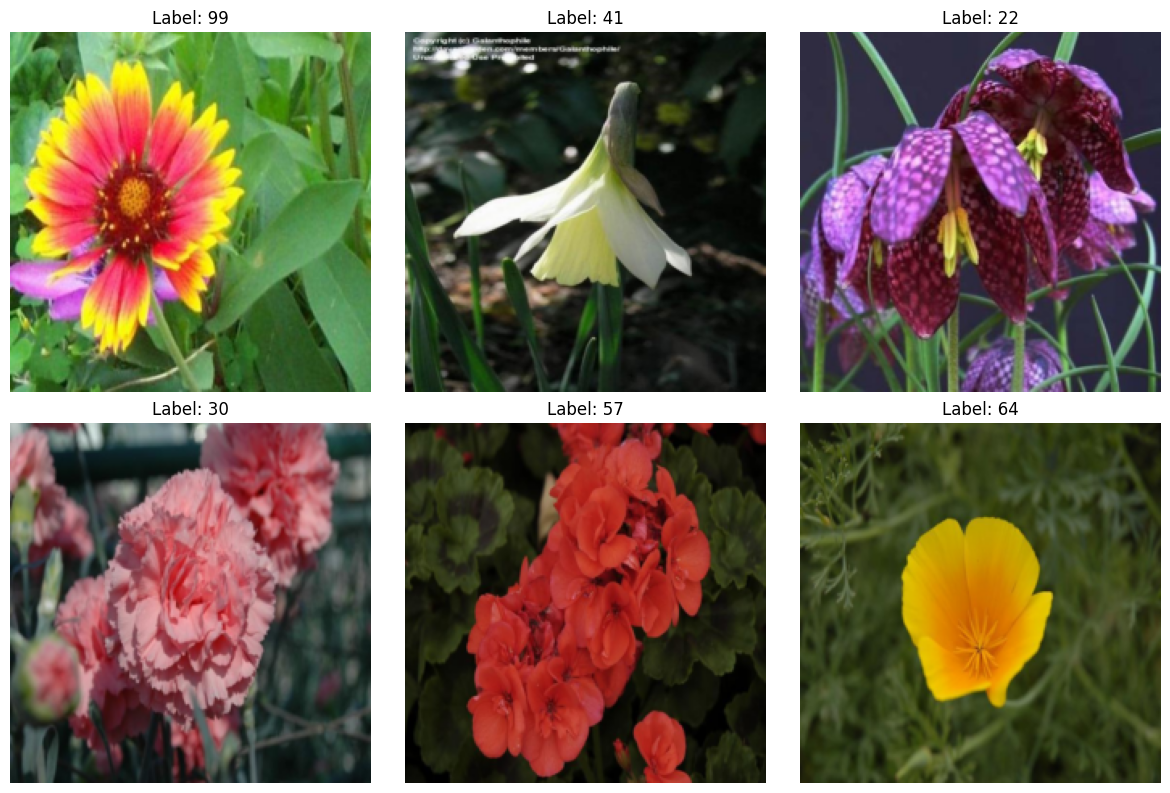

In [3]:
import matplotlib.pyplot as plt

# Get one batch
images, labels = next(iter(dataloader))

# Display first 6 images
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for i, ax in enumerate(axes.flat):
    img = images[i].permute(1, 2, 0)  # CHW → HWC
    ax.imshow(img)
    ax.set_title(f"Label: {labels[i].item()}")
    ax.axis("off")

plt.tight_layout()
plt.show()

Total Classes: 102
Images per class (first 10 classes):
Class 0: 10 images
Class 1: 10 images
Class 2: 10 images
Class 3: 10 images
Class 4: 10 images
Class 5: 10 images
Class 6: 10 images
Class 7: 10 images
Class 8: 10 images
Class 9: 10 images


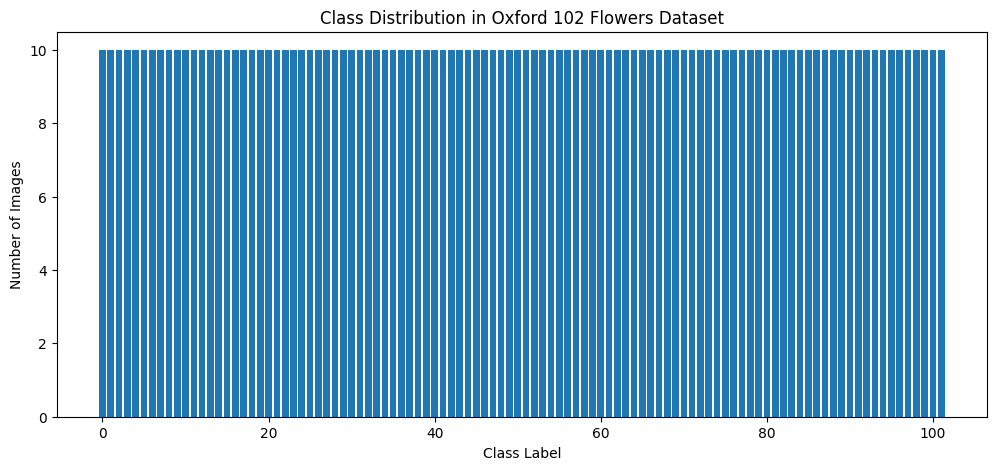

In [4]:
from collections import Counter
import matplotlib.pyplot as plt

# Extract all labels
all_labels = [label for _, label in dataset]

# Count labels
label_counts = Counter(all_labels)

print("Total Classes:", len(label_counts))
print("Images per class (first 10 classes):")

for cls, count in list(label_counts.items())[:10]:
    print(f"Class {cls}: {count} images")

# Plot class distribution
plt.figure(figsize=(12, 5))
plt.bar(label_counts.keys(), label_counts.values())
plt.xlabel("Class Label")
plt.ylabel("Number of Images")
plt.title("Class Distribution in Oxford 102 Flowers Dataset")
plt.show()

In [5]:
img, label = dataset[0]

print("Image shape:", img.shape)
print("Label:", label)
print("Image height:", img.shape[1])
print("Image width:", img.shape[2])
print("Channels:", img.shape[0])

Image shape: torch.Size([3, 224, 224])
Label: 0
Image height: 224
Image width: 224
Channels: 3
